<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1707 | Val: 415 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 3.77e-04 | train loss 0.9809 acc 0.550 | val loss 0.6016 acc 0.759 *


[ResNet-50] Epoch   2/100 | LR: 3.77e-04 | train loss 0.6388 acc 0.698 | val loss 0.7120 acc 0.701


[ResNet-50] Epoch   3/100 | LR: 3.77e-04 | train loss 0.5433 acc 0.737 | val loss 0.6905 acc 0.725


[ResNet-50] Epoch   4/100 | LR: 3.77e-04 | train loss 0.5760 acc 0.763 | val loss 0.5984 acc 0.735 *


...

[ResNet-50] Epoch  11/100 | LR: 3.77e-04 | train loss 0.2496 acc 0.868 | val loss 0.5445 acc 0.836


[ResNet-50] Epoch  12/100 | LR: 3.77e-04 | train loss 0.2203 acc 0.903 | val loss 0.4878 acc 0.827


[ResNet-50] Epoch  13/100 | LR: 3.77e-04 | train loss 0.1618 acc 0.921 | val loss 0.6840 acc 0.800


[ResNet-50] Epoch  14/100 | LR: 3.77e-04 | train loss 0.1583 acc 0.921 | val loss 0.5873 acc 0.814


[ResNet-50] Epoch  15/100 | LR: 3.77e-04 | train loss 0.2088 acc 0.903 | val loss 0.4678 acc 0.848

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 15.

[ResNet-50] Restored best checkpoint (val loss = 0.4262)


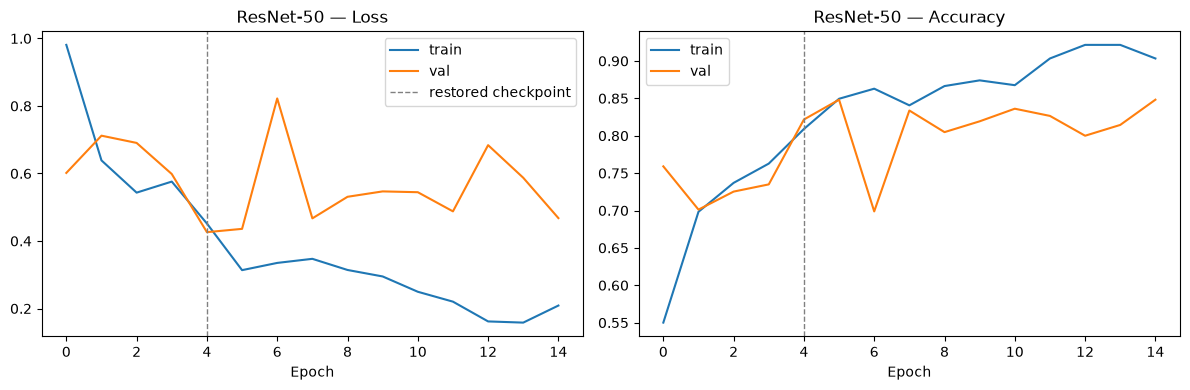

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.874


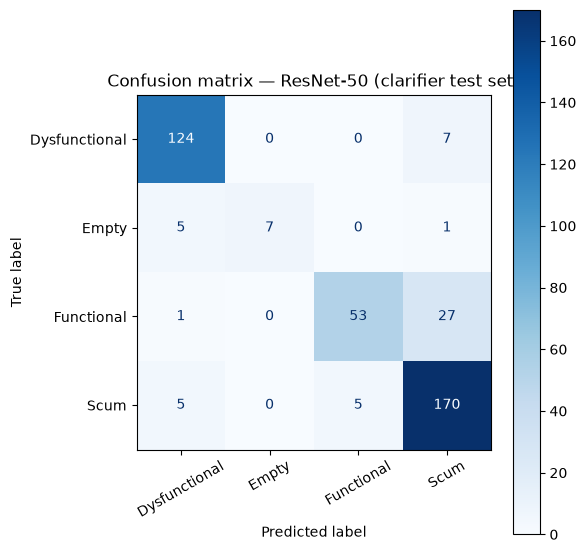

               precision    recall  f1-score   support

Dysfunctional      0.919     0.947     0.932       131
        Empty      1.000     0.538     0.700        13
   Functional      0.914     0.654     0.763        81
         Scum      0.829     0.944     0.883       180

     accuracy                          0.874       405
    macro avg      0.915     0.771     0.820       405
 weighted avg      0.881     0.874     0.869       405



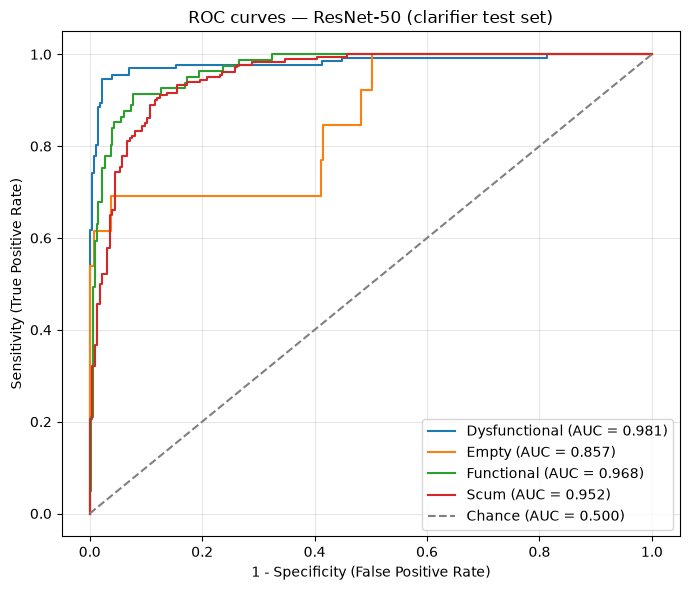

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.981
  Empty          : 0.857
  Functional     : 0.968
  Scum           : 0.952

Mean AUC (over 4/4 classes with test examples): 0.940


(np.float64(0.8740740740740741),
 {'Dysfunctional': 0.9811667688193012,
  'Empty': 0.8571428571428571,
  'Functional': 0.9677259564090839,
  'Scum': 0.9522469135802469})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/clarifier_aug/results_clarifier_resnet50_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
